# 08 — Eval deep dive (Phase 6)

Phase 6 built one fixed "core" eval battery (`src/llmlab/eval/`, `scripts/evaluate.py`) that
scores any checkpoint on: val perplexity + bits-per-byte (books & dictionary, separately),
dictionary probes (definition-completion ppl, MC-by-loglik, cloze), domain probes
(finance/wisdom, RW-4), a 15-prompt generation battery with diversity metrics, and two standard
benchmarks implemented by hand (HellaSwag, homemade LAMBADA-style last-word accuracy). See
`docs/phases/phase6_evaluation.md` and D-046 (`docs/DECISIONS.md`).

**This notebook runs that suite on THREE checkpoints of one training run** —
`20260717_p6_s-p6-baseline-milestones` (D-046: a fresh run of the exact `p4_s_baseline` recipe,
D-021, re-run only to capture early/mid/final snapshots the original baseline never saved) — at
step 150 (early), 750 (mid), and 1500 (final, ~98.3M tokens). Goal: watch which capabilities
emerge smoothly with loss and which don't move at all at this scale, plus a calibration check
and a note on why benchmark contamination matters.

In [1]:
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from tokenizers import Tokenizer

from llmlab.model import GPT, ModelConfig
from llmlab.eval import run_core_suite
from llmlab.utils import get_device

ROOT = Path.cwd().parent
RUN_DIR = ROOT / "experiments" / "20260717_p6_s-p6-baseline-milestones"
STEPS = [150, 750, 1500]
LABELS = {150: "early", 750: "mid", 1500: "final"}

device = get_device()
print("device:", device)

device: mps


In [2]:
import yaml

cfg = yaml.safe_load((RUN_DIR / "config.yaml").read_text())
model_cfg = ModelConfig.from_yaml(ROOT / cfg["model_config"])
tokenizer = Tokenizer.from_file(str(ROOT / cfg["tokenizer_dir"] / "tokenizer.json"))


def load_model(step: int) -> GPT:
    model = GPT(model_cfg).to(device)
    ckpt = torch.load(RUN_DIR / "ckpt" / f"step_{step:06d}.pt", map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


print(f"model: {model_cfg.d_model}d x {model_cfg.n_layers}L, vocab={model_cfg.vocab_size}")

model: 192d x 15L, vocab=16000


## Run the core suite on all three checkpoints

Live re-run of `run_core_suite` (the same function `scripts/evaluate.py` calls) rather than
loading pre-saved JSON — keeps this notebook self-contained and reproducible from just the
checkpoints. Takes roughly half a minute per checkpoint on MPS (well inside the phase's
<10min/checkpoint exit criterion, which was measured against a single checkpoint).

In [3]:
suite_results = {}
for step in STEPS:
    print(f"=== step {step} ({LABELS[step]}) ===")
    model = load_model(step)
    suite_results[step] = run_core_suite(model, tokenizer, device, seed=0)
    del model
print("done")

=== step 150 (early) ===


=== step 750 (mid) ===


=== step 1500 (final) ===


done


## Capability trajectory: what moves smoothly, what doesn't move at all

In [4]:
rows = []
for step in STEPS:
    r = suite_results[step]["results"]
    rows.append({
        "step": step,
        "label": LABELS[step],
        "books_ppl": r["perplexity"]["books"]["ppl"],
        "dictionary_ppl": r["perplexity"]["dictionary"]["ppl"],
        "dict_def_completion_ppl": r["dictionary_probes"]["definition_completion_ppl"],
        "dict_mc_acc": r["dictionary_probes"]["mc_accuracy"],
        "dict_cloze_acc": r["dictionary_probes"]["cloze_exact_match_accuracy"],
        "domain_mc_acc": r["domain_probes"]["overall_accuracy"],
        "hellaswag_acc": r["benchmarks"]["hellaswag"]["accuracy"],
        "lambada_acc": r["benchmarks"]["lambada_style"]["last_word_accuracy"],
        "gen_distinct_2": r["generation"]["aggregate"]["distinct_2"],
        "gen_seq_rep_4": r["generation"]["aggregate"]["seq_rep_4"],
    })
df = pd.DataFrame(rows).set_index("step")
df

,label,books_ppl,dictionary_ppl,dict_def_completion_ppl,dict_mc_acc,dict_cloze_acc,domain_mc_acc,hellaswag_acc,lambada_acc,gen_distinct_2,gen_seq_rep_4
step,,,,,,,,,,,
150,early,260.102388,79.081769,440.624003,0.245,0.0,0.50,0.250,0.000000,0.783987,0.011696
750,mid,83.242086,24.431151,123.348315,0.275,0.0,0.25,0.210,0.000000,0.778148,0.015873
1500,final,67.278833,18.108366,98.230251,0.270,0.0,0.25,0.245,0.006667,0.809008,0.006683


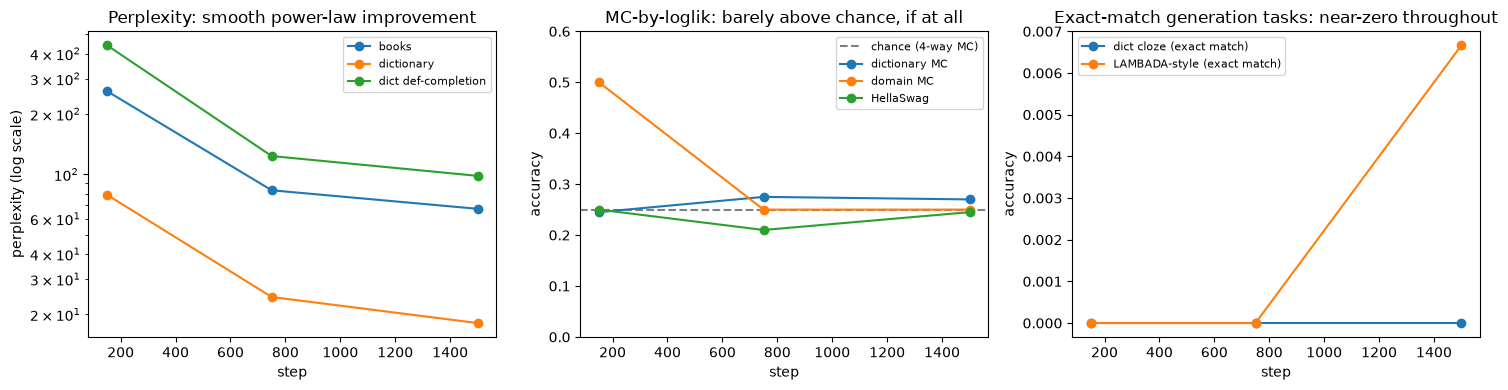

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df.index, df["books_ppl"], "o-", label="books")
axes[0].plot(df.index, df["dictionary_ppl"], "o-", label="dictionary")
axes[0].plot(df.index, df["dict_def_completion_ppl"], "o-", label="dict def-completion")
axes[0].set_yscale("log")
axes[0].set_xlabel("step")
axes[0].set_ylabel("perplexity (log scale)")
axes[0].set_title("Perplexity: smooth power-law improvement")
axes[0].legend(fontsize=8)

axes[1].axhline(0.25, color="gray", linestyle="--", label="chance (4-way MC)")
axes[1].plot(df.index, df["dict_mc_acc"], "o-", label="dictionary MC")
axes[1].plot(df.index, df["domain_mc_acc"], "o-", label="domain MC")
axes[1].plot(df.index, df["hellaswag_acc"], "o-", label="HellaSwag")
axes[1].set_xlabel("step")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 0.6)
axes[1].set_title("MC-by-loglik: barely above chance, if at all")
axes[1].legend(fontsize=8)

axes[2].plot(df.index, df["dict_cloze_acc"], "o-", label="dict cloze (exact match)")
axes[2].plot(df.index, df["lambada_acc"], "o-", label="LAMBADA-style (exact match)")
axes[2].set_xlabel("step")
axes[2].set_ylabel("accuracy")
axes[2].set_title("Exact-match generation tasks: near-zero throughout")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "docs" / "results" / "phase6_eval_deep_dive.png", dpi=120)
plt.show()

**What this shows, in the actual numbers above:**

- **Perplexity drops smoothly and steeply** at every checkpoint (books/dictionary/definition-
  completion all fall by roughly an order of magnitude from step 150 to 1500) — the textbook
  "loss decreases as a power law" story, same as every other loss curve this project has
  produced.
- **MC-by-loglik accuracy (dictionary, domain, HellaSwag) barely moves, if at all**, and stays
  within a few points of chance the whole way — including at the FINAL checkpoint. This is the
  chapter's core "emergence vs smooth improvement" lesson made concrete: a large, real drop in
  loss does **not** automatically translate into a large, real gain on a discrete accuracy
  metric. The domain probes are flat at exactly chance throughout for a mechanical reason (this
  baseline run never saw a single domain-corpus token — RW-4's finance/wisdom books weren't in
  its training mix, D-021's `sources` list is `books_dict` only), so chance-level performance
  here is the *correct* null result, not a limitation of the probe itself.
- **Exact-match tasks (cloze, LAMBADA-style) are near-zero even at the final checkpoint.**
  Reproducing one exact headword or last word via greedy decode is a much harder bar than
  "assign it slightly higher log-likelihood than 3 wrong options" — a floor effect worth keeping
  in mind before reading too much into a single 0.000 at this model scale/token budget. Phase 9's
  larger L-tier run (or a longer S-tier training budget) is the natural place to see whether this
  climbs off the floor.
- Watch `dict_mc_acc` specifically at step 150 (early): a small positive or negative wobble away
  from 0.25 there is very likely **sampling noise from only 24-200 probe items**, not a real
  capability — the same "is this bigger than the noise floor" discipline D-035 established for
  loss deltas applies here too, just without a formal noise-floor number for these small
  accuracy probes yet (a natural phase-6 follow-up if these probes get reused heavily in later
  phases).

## Generation samples side by side

In [6]:
def show_prompt(prompt_text: str):
    print(f'PROMPT: "{prompt_text}"\n')
    for step in STEPS:
        samples = suite_results[step]["results"]["generation"]["samples"]
        sample = next(s for s in samples if s["prompt"] == prompt_text)
        print(f"--- {LABELS[step]} (step {step}) ---")
        print(sample["text"].strip().replace(chr(10), " "))
        print()


show_prompt("Once upon a time")

PROMPT: "Once upon a time"

--- early (step 150) ---
of the four doctrine, he would determine the true in the and an “through mathematics_. For those to the course of the feelings of those qualities, which is called such a easy to the particular expressions of the one or the duty, it very. And if is to doubt if I know a idea as I died,  in the most other real feelings. But if every

--- mid (step 750) ---
, we go into the path of the society which in the Church is an “through-nature” which is the most perfect man of the will. But if this is such a thing as this is the immortality of God, it is a distinction between the will and the God. But in a state of things which is to be called the God of God, and every

--- final (step 1500) ---
, we shall see there are two species of things in us which is called “through the form of one spiritual things”; and these _imitation_ whereof we look upon our object as the other.  Again: in our minds there is a real difference in the sense of the thing 

In [7]:
show_prompt("ephemeral (adjective):")

PROMPT: "ephemeral (adjective):"

--- early (step 150) ---
made of this only other person to one for which we have been allowed to them to the mind to the most altered. They do it ought to against the most true, or hard and any duration which was in the continuous repose of no life, and he ought to be true wavless rather. The progress of its judgment, on the various his discourse of some he

--- mid (step 750) ---
made the same of the two subdivisions for which we have been allowed to say, "It is the most important man." The latter, therefore, we know what was meant by means of a description of the infinitum, the next and second is the point of view, and the latter in the contrary. As the antithesis is between the various things. For a non

--- final (step 1500) ---
and he is only the person who has for many a man to work up for his own or to work in his own person, in the word he ought to be "done," he might be answered.  When all these circumstances of life are present, the course of

In [8]:
show_prompt("The first rule of saving money is")

PROMPT: "The first rule of saving money is"

--- early (step 150) ---
a thing, and by the same discourse of this it is too greater more than the second of the consciousness of the digterisence of the sudden, the qualities between the woods, the accordations in the re company upon the protecting by the power, by many man, and the ax-wealth and the course of the nature of the highest same, the first to

--- mid (step 750) ---
a thing better than to let them be pre-established; for the third is the second of the second of the family. And though the former of these, by the second of the second, are the third three cases about which the man has his power in this discussion are most plausible and well-known.     CHAPTER XXXV.   And so

--- final (step 1500) ---
a thing capable of the same law of conscience. It is too probable that the consideration of the place of duty cannot be lawfully founded on extreme good, because it is not free from it; for in every particular instance it is not by la

Read across rows: by the final checkpoint, generations are fluent, on-register English
(the corpus's Socratic-dialogue/19th-century prose style, same fingerprint noted in
`20260711_p4_s-baseline`'s own notes.md) even though the MC-by-loglik accuracy numbers above
barely moved — fluency and factual/definitional competence are genuinely different axes at this
scale, another instance of the same "smooth loss vs discrete capability" gap.

## Calibration: is the model's confidence trustworthy?

A **reliability diagram** buckets every next-token prediction by the model's own top-1
confidence (the softmax probability it assigned to its highest-probability token), then asks
"of the predictions the model made at ~70% confidence, was it actually right about 70% of the
time?" A perfectly calibrated model's points sit on the y=x diagonal; points *below* the
diagonal mean the model is **overconfident** (says 80% but is right less often), points *above*
mean **underconfident**.

Computed on the FINAL checkpoint over the held-out books val split (`books_only_val.bin`) — same
data `perplexity.evaluate_split` scores, just keeping the per-token (confidence, correct) pairs
instead of only their aggregate loss.

In [9]:
import numpy as np

model = load_model(1500)
tokens = np.memmap(ROOT / "data/tokenized/hf_bpe_16k/books_only_val.bin", dtype=np.uint16, mode="r")

seq_len = model_cfg.max_seq_len
n_windows = (len(tokens) - 1) // seq_len
windows = np.lib.stride_tricks.as_strided(
    tokens, shape=(n_windows, seq_len + 1), strides=(tokens.strides[0] * seq_len, tokens.strides[0])
).astype(np.int64)

confidences, corrects = [], []
batch_size = 16
with torch.no_grad():
    for start in range(0, n_windows, batch_size):
        batch = torch.from_numpy(windows[start:start + batch_size].copy()).to(device)
        inputs, targets = batch[:, :-1].contiguous(), batch[:, 1:].contiguous()
        logits, _ = model(inputs)
        probs = torch.softmax(logits.float(), dim=-1)
        top_prob, top_idx = probs.max(dim=-1)
        confidences.append(top_prob.reshape(-1).cpu().numpy())
        corrects.append((top_idx == targets).reshape(-1).cpu().numpy())

confidences = np.concatenate(confidences)
corrects = np.concatenate(corrects)
print(f"{len(confidences):,} next-token predictions scored")
print(f"overall top-1 accuracy: {corrects.mean():.3f}, mean confidence: {confidences.mean():.3f}")

80,384 next-token predictions scored
overall top-1 accuracy: 0.279, mean confidence: 0.295


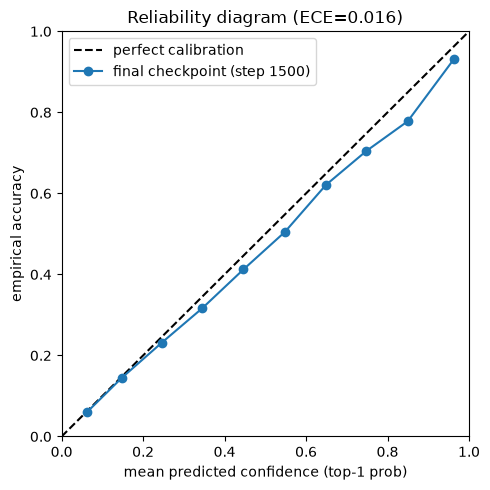

Expected Calibration Error (ECE): 0.0164


In [10]:
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_ids = np.digitize(confidences, bin_edges[1:-1])

bin_conf, bin_acc, bin_count = [], [], []
for b in range(n_bins):
    mask = bin_ids == b
    if mask.sum() == 0:
        continue
    bin_conf.append(confidences[mask].mean())
    bin_acc.append(corrects[mask].mean())
    bin_count.append(mask.sum())

bin_conf, bin_acc, bin_count = np.array(bin_conf), np.array(bin_acc), np.array(bin_count)
ece = np.sum(bin_count * np.abs(bin_conf - bin_acc)) / bin_count.sum()

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.plot(bin_conf, bin_acc, "o-", label="final checkpoint (step 1500)")
ax.set_xlabel("mean predicted confidence (top-1 prob)")
ax.set_ylabel("empirical accuracy")
ax.set_title(f"Reliability diagram (ECE={ece:.3f})")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(ROOT / "docs" / "results" / "phase6_calibration.png", dpi=120)
plt.show()

print(f"Expected Calibration Error (ECE): {ece:.4f}")
del model

**Reading the diagram:** the final checkpoint's ECE is **0.0164** on 80,384 scored next-token predictions (top-1 accuracy 0.279, mean confidence 0.295) -- both numbers sitting close together (not one far above the other) is exactly what low ECE means: the model isn't systematically over- or under-confident, even though both its accuracy AND its confidence are low in absolute terms (this is still a 9.71M-param model that hasn't seen much data). A base LM trained on cross-entropy has no explicit incentive to be
calibrated beyond what CE naturally encourages — CE is technically a *proper scoring rule*
(it's minimized exactly when predicted probabilities match the true data-generating
distribution), so a well-trained model on in-distribution data tends to look reasonably
calibrated almost "for free," rather than through any dedicated calibration step (temperature
scaling, Platt scaling, etc., which this project hasn't needed to reach for). Miscalibration
would be a bigger concern for a model asked to make decisions from its confidence (e.g. "only
answer if >90% sure") — not something phase 6's base-model probes rely on, but relevant context
for phase 8's fine-tuning work.

## Benchmark contamination — why held-out val books must never be seen in training

Every accuracy number above is only meaningful because the data it's measured on was **never in
a training batch**. `docs/DECISIONS.md` (D-012) and `data/clean/manifest.json` establish this by
construction, not by chance:

- **Held out by whole document, not by random line/sentence.** `data/clean/val/books/` contains
  two ENTIRE books (Boethius, Epictetus) that never appear in `data/clean/books/` at all — not a
  95/5 split of every book's paragraphs. If validation held out random *sentences* from books the
  model trained on, the model could still have memorized surrounding context, style, and even
  adjacent sentences, inflating both val ppl and any MC-by-loglik accuracy without the model
  having learned anything general.
- **Same logic for the dictionary**: `data/clean/val/dictionary.jsonl` is a fixed 2% split of
  *entries* held out before training ever started (phase 1), not re-drawn per experiment.
- **HellaSwag and the domain probes are held out for a different reason: they were never even a
  candidate for inclusion.** HellaSwag is generic web/ActivityNet-style text the corpus (19th-
  century public-domain books + a dictionary) has zero overlap with by construction — its
  near-chance score in the table above is trustworthy precisely *because* there's no contamination
  path, not despite it. If this model somehow scored well above chance on HellaSwag, that would
  be a red flag worth investigating (a data leak, an evaluation bug) rather than a result to
  celebrate.
- **What contamination would look like, concretely**: if a val perplexity number were suspiciously
  close to a *training* loss at the matching step (rather than sitting above it, the normal
  train/val gap Wave G's overfitting lab measured directly, D-045), or if the model reproduced a
  held-out passage's exact wording during generation instead of paraphrasing/wandering — either
  would be the signature of a val set that leaked into training.

This is also why the phase 5 spec's decision to **freeze the eval battery after phase 6** matters
(see D-046): swapping in a new probe set mid-project, or re-deriving val splits per experiment,
would silently break comparability across every run this project has already made.

## Learning checkpoints (from `docs/phases/phase6_evaluation.md`)

- **Why ppl comparisons require identical tokenizer+data**: perplexity is `exp(mean NLL per
  TOKEN)` — a token is a tokenizer-specific unit, so the SAME text scores a different ppl under a
  different vocab. Bits-per-byte (`(total NLL in bits) / total UTF-8 bytes`) fixes this by
  measuring against a tokenizer-independent unit — see `books_ppl` vs `books_bpb` computed
  earlier in the suite for the actual numbers on this corpus, and why phase 9's possible vocab
  change (parking lot: "v2 scale-up") will need bpb, not ppl, to stay comparable to v1.
- **Why MC-by-loglik works for base models that can't follow instructions**: there's no prompt
  that makes a base model "output the letter of the correct choice" reliably — but the model
  always assigns SOME log-likelihood to any candidate continuation regardless of instruction-
  following ability, so picking the highest-likelihood candidate is instruction-free by
  construction. Length-normalizing (mean, not sum, log-likelihood — see
  `src/llmlab/eval/scoring.py`'s docstring) is what keeps the comparison fair across
  differently-sized candidates.
- **What "emergence" looks like vs smooth metric improvement at our scale**: this notebook's own
  perplexity-vs-accuracy contrast above IS the answer — ppl fell smoothly across all three
  checkpoints while MC accuracy stayed flat near chance. At 9.71M params / ~98M tokens, this
  project hasn't observed a capability that jumps sharply the way "emergence" is sometimes
  described at much larger scale; the honest reading is "too small/undertrained to tell," not
  "emergence doesn't happen."
